# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset collected is related to 17 campaigns

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import time
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [6]:
df.shape

(41188, 21)

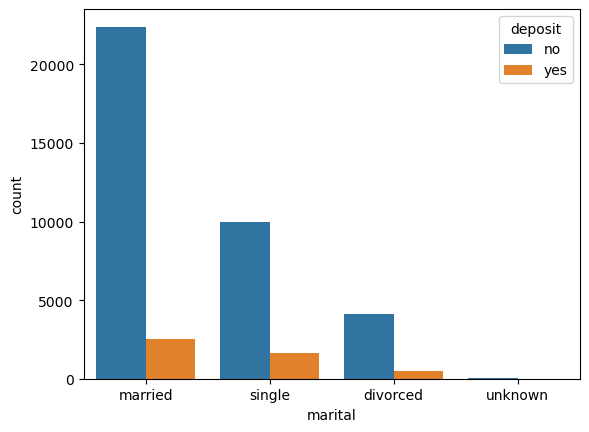

In [7]:
df.rename(columns={'y':'deposit'}, inplace=True)
ax = sns.countplot(x='marital', hue = 'deposit', data = df)

In [8]:
df['deposit'].value_counts()

deposit
no     36548
yes     4640
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'basic.4y'),
  Text(1, 0, 'high.school'),
  Text(2, 0, 'basic.6y'),
  Text(3, 0, 'basic.9y'),
  Text(4, 0, 'professional.course'),
  Text(5, 0, 'unknown'),
  Text(6, 0, 'university.degree'),
  Text(7, 0, 'illiterate')])

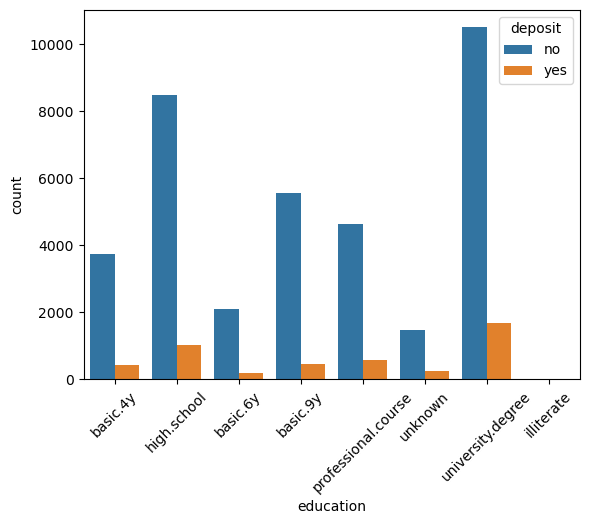

In [9]:
ax = sns.countplot(x='education', hue='deposit', data=df)
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'housemaid'),
  Text(1, 0, 'services'),
  Text(2, 0, 'admin.'),
  Text(3, 0, 'blue-collar'),
  Text(4, 0, 'technician'),
  Text(5, 0, 'retired'),
  Text(6, 0, 'management'),
  Text(7, 0, 'unemployed'),
  Text(8, 0, 'self-employed'),
  Text(9, 0, 'unknown'),
  Text(10, 0, 'entrepreneur'),
  Text(11, 0, 'student')])

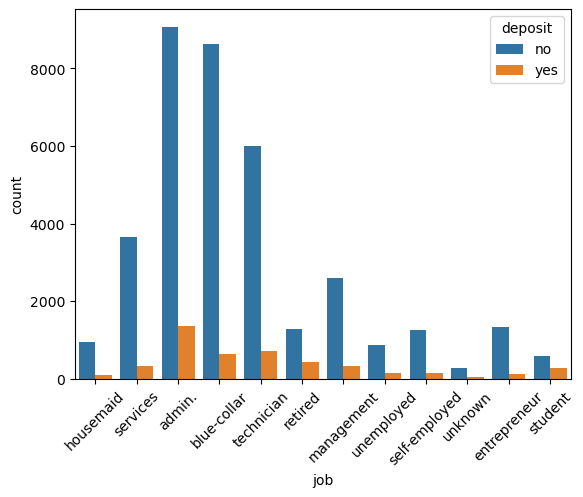

In [10]:
ax = sns.countplot(x='job', hue='deposit', data=df)
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Bar plot of deposit by credit status')

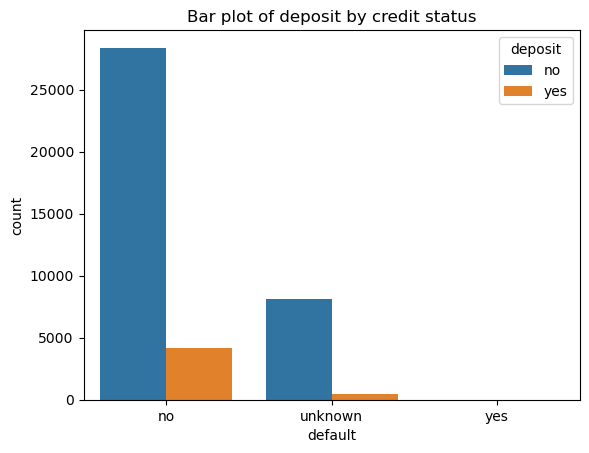

In [11]:
ax = sns.countplot(x ='default', hue = "deposit", data = df)
ax.set_title('Bar plot of deposit by credit status')

In [12]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Text(0.5, 1.0, 'Bar plot of deposit by contact')

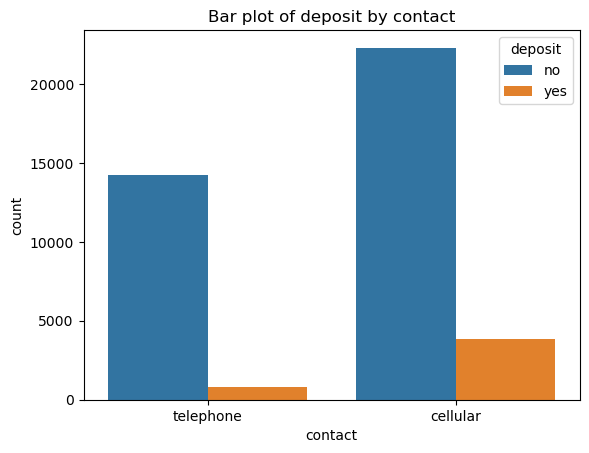

In [13]:
ax = sns.countplot(x ='contact', hue = "deposit", data = df)
ax.set_title('Bar plot of deposit by contact')

Text(0.5, 1.0, 'Bar plot of deposit by month')

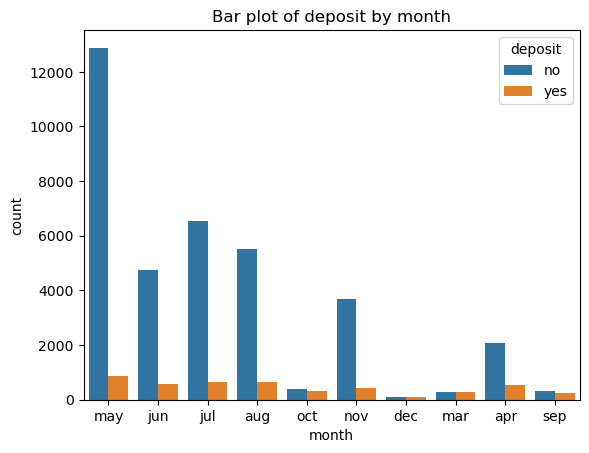

In [14]:
ax = sns.countplot(x ='month', hue = "deposit", data = df)
ax.set_title('Bar plot of deposit by month')

Text(0.5, 1.0, 'Bar plot of deposit by day_of_week')

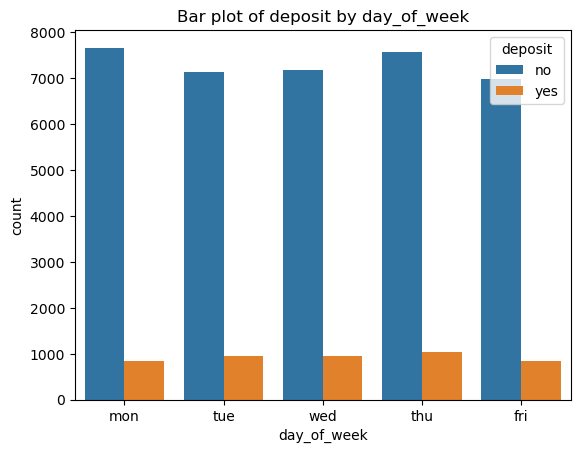

In [15]:
ax = sns.countplot(x ='day_of_week', hue = "deposit", data = df)
ax.set_title('Bar plot of deposit by day_of_week')

Text(0.5, 1.0, 'Bar plot of deposit by poutcome')

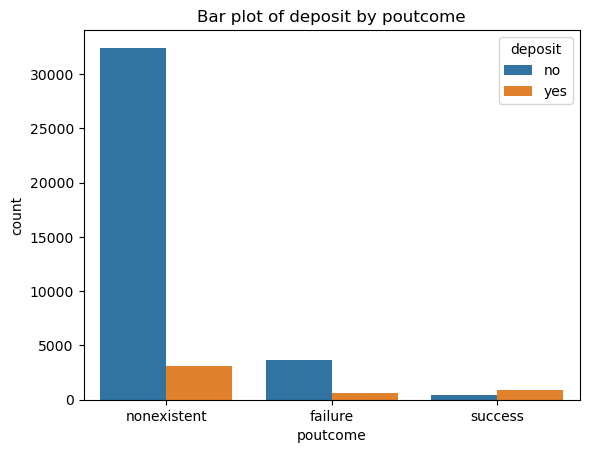

In [8]:
ax = sns.countplot(x ='poutcome', hue = "deposit", data = df)
ax.set_title('Bar plot of deposit by poutcome')

This dataset was provided for a Portugese banking as a collection of multiple marketing campaign results.  

From a business objective, the task of this Machine Learning project is to determine which factors could lead to a higher success rates to sign up for the long term deposit product.

How does loan products have a positive impact on customer success rate?
Are we going to have a better success rate with customers with better education?
How does the contact method affect the success rate?

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [9]:
# select the following columns as features:

# job	marital	education	default	housing	loan	contact	month	day_of_week poutcome  totally 10 columns

feature_cols = ['job', 'marital', 'education', 'default', 'housing','loan', 'contact','month','day_of_week','poutcome']

X=df[feature_cols]
y=df['deposit']

X.head()


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent


In [10]:
columns_trans = make_column_transformer((OneHotEncoder(handle_unknown='ignore'),
                                        ['job','marital','education','default','contact','month','day_of_week','poutcome']),
                                       (OrdinalEncoder(),['housing','loan']),
                                       remainder='passthrough')
columns_trans.fit(X)

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'contact', 'month', 'day_of_week',
                                  'poutcome']),
                                ('ordinalencoder', OrdinalEncoder(),
                                 ['housing', 'loan'])])

In [11]:
le=LabelEncoder()
le.fit_transform(y)

array([0, 0, 0, ..., 0, 1, 0])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [13]:
# use dummy classifier as base line model

from sklearn.dummy import DummyClassifier

dmy_pipe = Pipeline([
    ('transformer',columns_trans),
    ('scale', StandardScaler(with_mean=False)),
    ('model', DummyClassifier())
])

In [15]:
dmy = dmy_pipe.fit(X_train, y_train)
dmy_pred = dmy.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
accuracy = accuracy_score(y_test, dmy_pred)
precision = precision_score(y_test, dmy_pred, average='macro')
recall=recall_score(y_test, dmy_pred, average='macro')
f1=f1_score(y_test, dmy_pred, average='macro')

print("Accuracy: {:.6f}".format(accuracy))
print("Precision: {:.6f}".format(precision))
print("Recall: {:.6f}".format(recall))
print("F1-score: {:.6f}".format(f1))

Accuracy: 0.887594
Precision: 0.443797
Recall: 0.500000
F1-score: 0.470225


C:\Users\JPM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


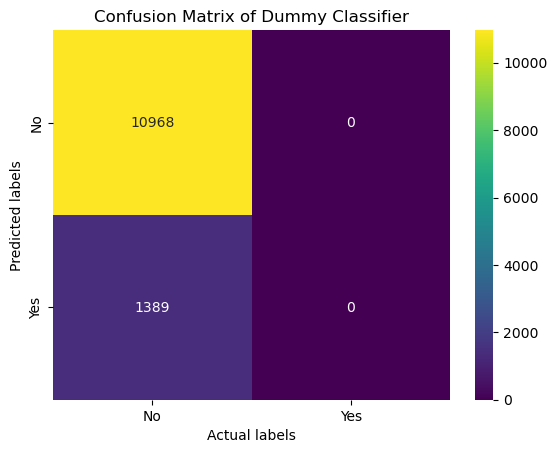

In [24]:
ax = plt.subplot()
conf_matrix = confusion_matrix(y_test,dmy_pred)
sns.heatmap(conf_matrix, annot = True, cmap = 'viridis', fmt = 'd', ax=ax)

# labels, title and ticks
ax.set_xlabel('Actual labels');ax.set_ylabel('Predicted labels'); 
ax.set_title('Confusion Matrix of Dummy Classifier'); 
ax.xaxis.set_ticklabels(['No', 'Yes']); 
ax.yaxis.set_ticklabels(['No', 'Yes']);

#plt.xlabel('Predicted')
#plt.ylabel('Actual')
plt.show()

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [25]:
%%time
# building a logistic regression model

lgr_pipe = Pipeline ([
    ('transformer', columns_trans),
    ('scale', StandardScaler(with_mean=False)),
    ('model', LogisticRegression())
])

lgr = lgr_pipe.fit(X_train,y_train)

lgr_pred = lgr.predict(X_test)

CPU times: total: 250 ms
Wall time: 260 ms


### Problem 9: Score the Model

What is the accuracy of your model?

In [26]:
lgr_accuracy = accuracy_score(y_test, lgr_pred)
lgr_precision = precision_score(y_test, lgr_pred, average='macro')
lgr_recall=recall_score(y_test, lgr_pred, average='macro')
lgr_f1=f1_score(y_test, lgr_pred, average='macro')

print("Logistic Model Accuracy: {:.6f}".format(lgr_accuracy))
print("Logistic Model Precision: {:.6f}".format(lgr_precision))
print("Logistic Model Recall: {:.6f}".format(lgr_recall))
print("Logistic Model F1-score: {:.6f}".format(lgr_f1))

Logistic Model Accuracy: 0.897386
Logistic Model Precision: 0.776924
Logistic Model Recall: 0.588828
Logistic Model F1-score: 0.619720


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [27]:
%%time
# Building a Logistic Regression Model

lgr1_pipe = Pipeline([
    ('transformer',columns_trans),
    ('scale', StandardScaler(with_mean=False)),
    ('model', LogisticRegression())
     ])

# Train the Classifiers
lgr1 = lgr1_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
lgr1_pred = lgr1.predict(X_test)

lgr1_train_score = lgr1.score(X_train, y_train)
lgr1_test_score = lgr1.score(X_test, y_test)

print("Train Accuracy: ", lgr1_train_score)
print("Test Accuracy: ", lgr1_test_score)

Train Accuracy:  0.8966737192605182
Test Accuracy:  0.8973860969490977
CPU times: total: 438 ms
Wall time: 443 ms


In [28]:
%%time
# Building a KNN Model

knn_pipe = Pipeline([
    ('transformer',columns_trans),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier())
     ])

# Train the Classifiers
knn = knn_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
knn_pred = knn.predict(X_test)

knn_train_score = knn.score(X_train, y_train)
knn_test_score = knn.score(X_test, y_test)

print("Train Accuracy: ", knn_train_score)
print("Test Accuracy: ", knn_test_score)

Train Accuracy:  0.9085012659984045
Test Accuracy:  0.8907501820830298
CPU times: total: 1min 6s
Wall time: 1min 7s


In [29]:
%%time
# Building a Decision Tree Model

dtc1_pipe = Pipeline([
    ('transformer',columns_trans),
    ('scale', StandardScaler(with_mean=False)),
    ('model', DecisionTreeClassifier())
     ])

# Train the Classifiers
dtc1 = dtc1_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
dtc1_pred = dtc1.predict(X_test)

dtc1_train_score = dtc1.score(X_train, y_train)
dtc1_test_score = dtc1.score(X_test, y_test)

print("Train Accuracy: ", dtc1_train_score)
print("Test Accuracy: ", dtc1_test_score)

Train Accuracy:  0.9521348548437446
Test Accuracy:  0.8648539289471554
CPU times: total: 1.25 s
Wall time: 1.27 s


In [30]:
%%time
# Building a SVC Model

svm1_pipe = Pipeline([
    ('transformer',columns_trans),
    ('scale', StandardScaler(with_mean=False)),
    ('model', SVC())
     ])

# Train the Classifiers
svm1 = svm1_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
svm1_pred = svm1.predict(X_test)

svm1_train_score = svm1.score(X_train, y_train)
svm1_test_score = svm1.score(X_test, y_test)

print("Train Accuracy: ", svm1_train_score)
print("Test Accuracy: ", svm1_test_score)

Train Accuracy:  0.9028823141757136
Test Accuracy:  0.8978716516953953
CPU times: total: 2min 8s
Wall time: 2min 9s


In [31]:
# Display the results in a dataframe

pd.DataFrame({'Model': ['Logistic Regression', 'KNN', 'Decistion Tree Classifier', 'SVM'],
              'Train Time (s)': ['0.500', '61', '1.2', '117'],
              'Train Accuracy': ['0.8966737192605182', '0.9085012659984045', '0.9521348548437446', '0.9028823141757136'],
              'Test Accuracy': ['0.8973860969490977', '0.8907501820830298', '0.8630735615440641', '0.8978716516953953']})

,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,0.500,0.8966737192605182,0.8973860969490977
1,KNN,61,0.9085012659984045,0.8907501820830298
2,Decistion Tree Classifier,1.2,0.9521348548437446,0.8630735615440641
3,SVM,117,0.9028823141757136,0.8978716516953953


From the results, we can see that Logistic Regression has the lowest training time.  Decision Tree has the best Train 
Accuracy.  SVM has the best test Accuracy.  Please note we were using default values for all the 4 models.  Decision 
tree model had apparent overfitting issue for this use case.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [32]:
lgr1_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'transformer', 'scale', 'model', 'transformer__force_int_remainder_cols', 'transformer__n_jobs', 'transformer__remainder', 'transformer__sparse_threshold', 'transformer__transformer_weights', 'transformer__transformers', 'transformer__verbose', 'transformer__verbose_feature_names_out', 'transformer__onehotencoder', 'transformer__ordinalencoder', 'transformer__onehotencoder__categories', 'transformer__onehotencoder__drop', 'transformer__onehotencoder__dtype', 'transformer__onehotencoder__feature_name_combiner', 'transformer__onehotencoder__handle_unknown', 'transformer__onehotencoder__max_categories', 'transformer__onehotencoder__min_frequency', 'transformer__onehotencoder__sparse_output', 'transformer__ordinalencoder__categories', 'transformer__ordinalencoder__dtype', 'transformer__ordinalencoder__encoded_missing_value', 'transformer__ordinalencoder__handle_unknown', 'transformer__ordinalencoder__max_categories', 'transformer_

In [33]:
%%time
# hyperparamter tuning and grid search for Logistic Regression Model

params_lgr1 = {
    'model__penalty': ['l1', 'l2'],
    'model__C': np.logspace(-3,3,7),
    'model__solver': ['newton-cg', 'lbfgs', 'liblinear'],
}

# GridSearch 
gs_LR = GridSearchCV(estimator=lgr1_pipe,
                     param_grid=params_lgr1,
                     scoring='accuracy',
                     cv=10)

# train the GridSearch
gs_LR = gs_LR.fit(X_train, y_train)
gs_LR_pred = gs_LR.predict(X_test)

# print the modelt parameters of the best model
print('\nGrid Search best parameters:\n')
print(gs_LR.best_params_)

print('\nGrid Search CV results:\n')
print(gs_LR.cv_results_)

print('\nBest Parameters set:\n')
print(gs_LR.best_estimator_.steps)

# print the test score of the best model
print('Test Accurary: %.6f' % gs_LR.best_estimator_.score(X_test, y_test))
print('Best cross-validation score: ', gs_LR.best_score_)
score = gs_LR.score(X_test, y_test)
print("Test score: ", score)


C:\Users\JPM\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
140 fits failed out of a total of 420.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\JPM\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\JPM\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\JPM\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y


Grid Search best parameters:

{'model__C': np.float64(0.01), 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Grid Search CV results:

{'mean_fit_time': array([0.09796724, 0.10612903, 0.17687569, 0.24360282, 0.18207607,
       0.1854794 , 0.10216985, 0.09552119, 0.46888247, 0.34599752,
       0.24411671, 0.18346303, 0.12986996, 0.10428572, 0.70081451,
       0.30438116, 0.17098048, 0.18340478, 0.10495024, 0.09161   ,
       1.71750531, 0.26936982, 0.20724397, 0.180988  , 0.10151374,
       0.10373952, 0.24154961, 0.24129848, 0.19613197, 0.20794132,
       0.10101922, 0.10103874, 0.16408336, 0.24013863, 0.17748487,
       0.18557441, 0.09228899, 0.09724565, 0.17170227, 0.2376375 ,
       0.17686288, 0.18633792]), 'std_fit_time': array([0.01523214, 0.01093439, 0.02066933, 0.01697044, 0.0157222 ,
       0.01074837, 0.00706822, 0.0070001 , 0.12200684, 0.06239698,
       0.01337141, 0.01058196, 0.01598747, 0.00829699, 0.16048099,
       0.05774938, 0.0255026 , 0.01864538, 0.01426006,

In [34]:
knn_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'transformer', 'scale', 'model', 'transformer__force_int_remainder_cols', 'transformer__n_jobs', 'transformer__remainder', 'transformer__sparse_threshold', 'transformer__transformer_weights', 'transformer__transformers', 'transformer__verbose', 'transformer__verbose_feature_names_out', 'transformer__onehotencoder', 'transformer__ordinalencoder', 'transformer__onehotencoder__categories', 'transformer__onehotencoder__drop', 'transformer__onehotencoder__dtype', 'transformer__onehotencoder__feature_name_combiner', 'transformer__onehotencoder__handle_unknown', 'transformer__onehotencoder__max_categories', 'transformer__onehotencoder__min_frequency', 'transformer__onehotencoder__sparse_output', 'transformer__ordinalencoder__categories', 'transformer__ordinalencoder__dtype', 'transformer__ordinalencoder__encoded_missing_value', 'transformer__ordinalencoder__handle_unknown', 'transformer__ordinalencoder__max_categories', 'transformer_

In [35]:
%%time
# hyperparamter tuning and grid search for knn Model

params_knn = {'model__n_neighbors': range(1,18,2)}
    

# GridSearch 
gs_knn = GridSearchCV(estimator=knn_pipe,
                     param_grid=params_knn,
                     scoring='accuracy',
                     cv=10)

# train the GridSearch
gs_knn = gs_knn.fit(X_train, y_train)
gs_knn_pred = gs_knn.predict(X_test)

# print the modelt parameters of the best model
print('\nGrid Search best parameters:\n')
print(gs_knn.best_params_)

# print('\nGrid Search CV results:\n')
# print(gs_knn.cv_results_)

print('\nBest Parameters set:\n')
print(gs_knn.best_estimator_.steps)

# print the test score of the best model
print('Test Accurary: %.6f' % gs_knn.best_estimator_.score(X_test, y_test))
print('Best cross-validation score: ', gs_knn.best_score_)
score = gs_knn.score(X_test, y_test)
print("Test score: ", score)


Grid Search best parameters:

{'model__n_neighbors': 17}

Best Parameters set:

[('transformer', ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'contact', 'month', 'day_of_week',
                                  'poutcome']),
                                ('ordinalencoder', OrdinalEncoder(),
                                 ['housing', 'loan'])])), ('scale', StandardScaler(with_mean=False)), ('model', KNeighborsClassifier(n_neighbors=17))]
Test Accurary: 0.896820
Best cross-validation score:  0.8948355850427419
Test score:  0.8968196164117505
CPU times: total: 5min 50s
Wall time: 5min 52s


In [36]:
dtc1_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'transformer', 'scale', 'model', 'transformer__force_int_remainder_cols', 'transformer__n_jobs', 'transformer__remainder', 'transformer__sparse_threshold', 'transformer__transformer_weights', 'transformer__transformers', 'transformer__verbose', 'transformer__verbose_feature_names_out', 'transformer__onehotencoder', 'transformer__ordinalencoder', 'transformer__onehotencoder__categories', 'transformer__onehotencoder__drop', 'transformer__onehotencoder__dtype', 'transformer__onehotencoder__feature_name_combiner', 'transformer__onehotencoder__handle_unknown', 'transformer__onehotencoder__max_categories', 'transformer__onehotencoder__min_frequency', 'transformer__onehotencoder__sparse_output', 'transformer__ordinalencoder__categories', 'transformer__ordinalencoder__dtype', 'transformer__ordinalencoder__encoded_missing_value', 'transformer__ordinalencoder__handle_unknown', 'transformer__ordinalencoder__max_categories', 'transformer_

In [37]:
%%time
# hyperparamter tuning and grid search for DTC Model

# params_dtc = {'model__n_neighbors': range(1,18,2)}
params_dtc1 ={
    'model__min_samples_leaf': [1,2,3],
    'model__max_depth': [1,2,3],
    'model__criterion': ['entropy', 'gini', 'log_loss']
}

# GridSearch 
gs_dtc = GridSearchCV(estimator=dtc1_pipe,
                     param_grid=params_dtc1,
                     scoring='accuracy',
                     cv=10)

# train the GridSearch
gs_dtc = gs_dtc.fit(X_train, y_train)
gs_dtc_pred = gs_dtc.predict(X_test)

# print the modelt parameters of the best model
print('\nGrid Search best parameters:\n')
print(gs_dtc.best_params_)

# print('\nGrid Search CV results:\n')
# print(gs_dtc.cv_results_)

print('\nBest Parameters set:\n')
print(gs_dtc.best_estimator_.steps)

# print the test score of the best model
print('Test Accurary: %.6f' % gs_dtc.best_estimator_.score(X_test, y_test))
print('Best cross-validation score: ', gs_dtc.best_score_)
score = gs_dtc.score(X_test, y_test)
print("Test score: ", score)


Grid Search best parameters:

{'model__criterion': 'entropy', 'model__max_depth': 1, 'model__min_samples_leaf': 1}

Best Parameters set:

[('transformer', ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'contact', 'month', 'day_of_week',
                                  'poutcome']),
                                ('ordinalencoder', OrdinalEncoder(),
                                 ['housing', 'loan'])])), ('scale', StandardScaler(with_mean=False)), ('model', DecisionTreeClassifier(criterion='entropy', max_depth=1))]
Test Accurary: 0.897224
Best cross-validation score:  0.8975062216070773
Test score:  0.8972242453669984
CPU times: total: 47 s
Wall time: 47.4 s


In [38]:
svm1_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'transformer', 'scale', 'model', 'transformer__force_int_remainder_cols', 'transformer__n_jobs', 'transformer__remainder', 'transformer__sparse_threshold', 'transformer__transformer_weights', 'transformer__transformers', 'transformer__verbose', 'transformer__verbose_feature_names_out', 'transformer__onehotencoder', 'transformer__ordinalencoder', 'transformer__onehotencoder__categories', 'transformer__onehotencoder__drop', 'transformer__onehotencoder__dtype', 'transformer__onehotencoder__feature_name_combiner', 'transformer__onehotencoder__handle_unknown', 'transformer__onehotencoder__max_categories', 'transformer__onehotencoder__min_frequency', 'transformer__onehotencoder__sparse_output', 'transformer__ordinalencoder__categories', 'transformer__ordinalencoder__dtype', 'transformer__ordinalencoder__encoded_missing_value', 'transformer__ordinalencoder__handle_unknown', 'transformer__ordinalencoder__max_categories', 'transformer_

In [17]:
%%time
# hyperparamter tuning and grid search for SVM Model

#Redfined the Pipeline
svm_pipe_gs = Pipeline ([
    ('transformer', columns_trans),
    ('scale', StandardScaler(with_mean=False)),
    ('model', SVC(probability=False))
])

params_svm1 = {
    'model__C': [0.1, 0.5, 1.0],
    # 'model__gamma': [0.1, 1.0],
    # 'model__kernel': ['rbf','linear']
    'model__kernel': ['rbf']
}

# GridSearch 
gs_svm = GridSearchCV(estimator=svm_pipe_gs,
                     param_grid=params_svm1,
                     scoring='accuracy',
                     cv=10,
                     refit=True,
                     n_jobs=1)

# train the GridSearch
gs_svm = gs_svm.fit(X_train, y_train)
gs_svm_pred = gs_svm.predict(X_test)

# print the modelt parameters of the best model
print('\nGrid Search best parameters:\n')
print(gs_svm.best_params_)

# print('\nGrid Search CV results:\n')
# print(gs_svm.cv_results_)

print('\nBest Parameters set:\n')
print(gs_svm.best_estimator_.steps)

# print the test score of the best model
print('Test Accurary: %.6f' % gs_svm.best_estimator_.score(X_test, y_test))
print('Best cross-validation score: ', gs_svm.best_score_)
score = gs_svm.score(X_test, y_test)
print("Test score: ", score)


Grid Search best parameters:

{'model__C': 0.5, 'model__kernel': 'rbf'}

Best Parameters set:

[('transformer', ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'contact', 'month', 'day_of_week',
                                  'poutcome']),
                                ('ordinalencoder', OrdinalEncoder(),
                                 ['housing', 'loan'])])), ('scale', StandardScaler(with_mean=False)), ('model', SVC(C=0.5))]
Test Accurary: 0.897710
Best cross-validation score:  0.89740213928029
Test score:  0.8977098001132962
CPU times: total: 28min 47s
Wall time: 28min 53s


In [18]:
pd.DataFrame({'Model': ['Logistic', 'KNN','Decision Tree', 'SVM'], 
             'Train Time (s)': ['104','352','47.2','1733'],
             'Best Params': ['C:0.01, penalty:l1, solver: liblinear', 'n_neighbors: 17', 'criterion: entropy, max_depth: 1, model__min_samples_leaf: 1','C: 0.5, kernel: rbf'],
             'Best Score': ['0.8973674411623354','0.8948355850427419','0.8975062216070773','0.89740213928029']})

,Model,Train Time (s),Best Params,Best Score
0,Logistic,104,"C:0.01, penalty:l1, solver: liblinear",0.8973674411623354
1,KNN,352,n_neighbors: 17,0.8948355850427419
2,Decision Tree,47.2,"criterion: entropy, max_depth: 1, model__min_s...",0.8975062216070773
3,SVM,1733,"C: 0.5, kernel: rbf",0.89740213928029


##### Questions

The dataset is heavily unbalanced to the unsuccessful marketing campaign.  Maybe the models would be more useful to determine features which makes the campaign more unsuccessful.